###   Sales analysis

C:\Users\hriti\AppData\Local\Temp\ipykernel_25548\2560909260.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.resample('M', on='Order Date')['Revenue'].sum()


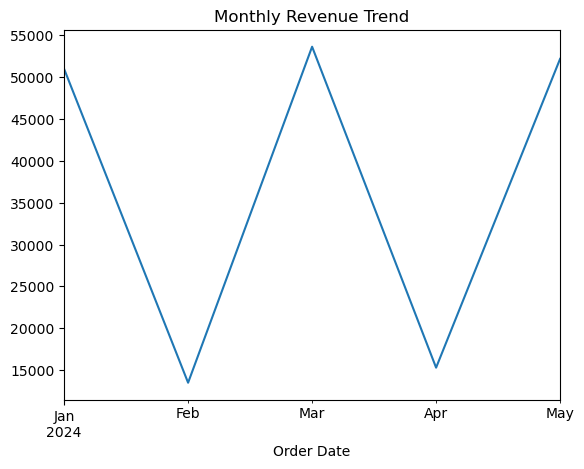

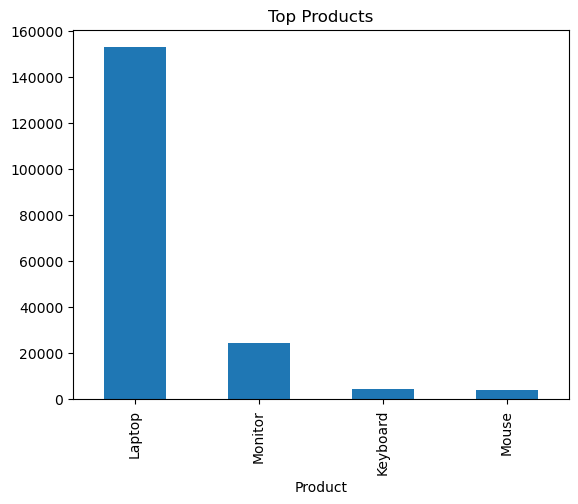

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Order ID": [1,2,3,4,5,6,7,8,9,10],
    "Order Date": ["2024-01-05","2024-01-10","2024-02-14","2024-02-20","2024-03-01","2024-03-15","2024-04-05","2024-04-18","2024-05-02","2024-05-20"],
    "Product": ["Laptop","Mouse","Keyboard","Monitor","Laptop","Mouse","Keyboard","Monitor","Laptop","Mouse"],
    "Region": ["North","South","East","West","North","South","East","West","North","South"],
    "Quantity": [1,2,1,1,1,3,2,1,1,2],
    "Price": [50000,500,1500,12000,52000,550,1400,12500,51000,600]
}

df = pd.DataFrame(data)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Revenue'] = df['Quantity'] * df['Price']

total_revenue = df['Revenue'].sum()
average_order_value = df.groupby('Order ID')['Revenue'].sum().mean()

top_regions = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

monthly_trend = df.resample('M', on='Order Date')['Revenue'].sum()

plt.figure()
monthly_trend.plot()
plt.title("Monthly Revenue Trend")
plt.savefig("trend.png")

plt.figure()
top_products.head(10).plot(kind='bar')
plt.title("Top Products")
plt.savefig("top_products.png")

summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Average Order Value"],
    "Value": [total_revenue, average_order_value]
})

summary.to_csv("summary.csv", index=False)

with open("report.txt", "w") as f:
    f.write("Sales Analysis Report\n")
    f.write(f"Total Revenue: {total_revenue}\n")
    f.write(f"Average Order Value: {average_order_value}\n\n")
    f.write("Top Regions:\n")
    f.write(top_regions.to_string())
    f.write("\n\nTop Products:\n")
    f.write(top_products.head(10).to_string())